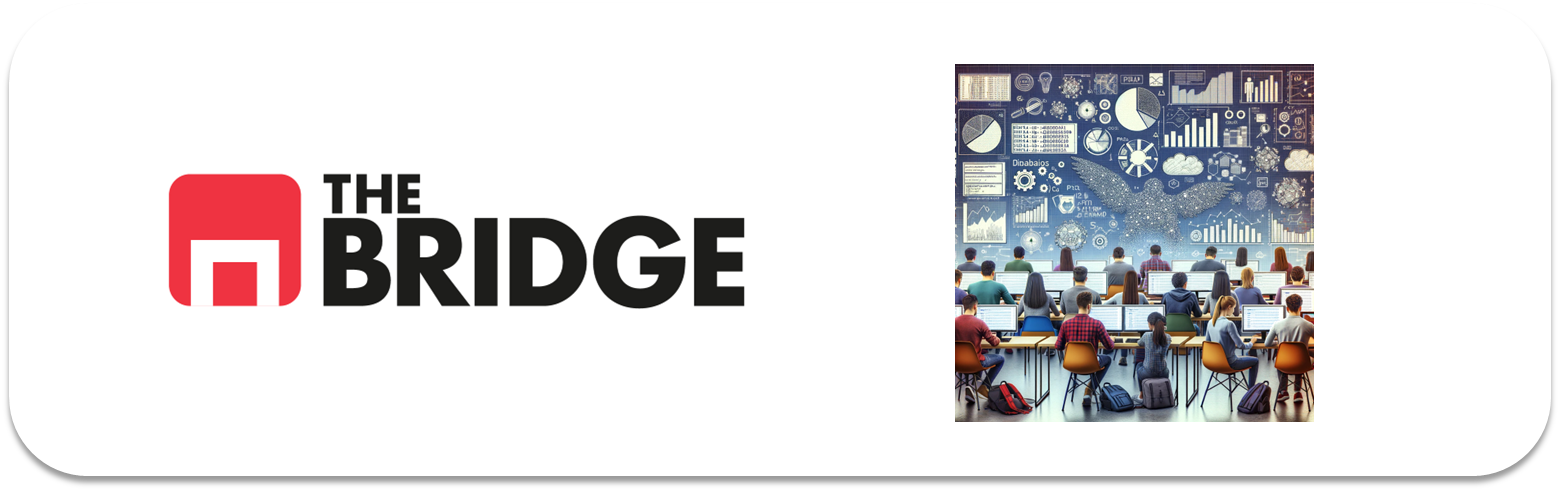

## PRACTICA OBLIGATORIA: **Regresion Lineal y Regularización**

* La práctica obligatoria de esta unidad consiste en hacer un modelado completo de un problema que ya conoces, la predicción de casas, pero con otro dataset. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Modelo de Regresión Lineal

El objetivo del modelo que tienes que construir es predecir la mediana del precio de las casas en una zona del área metropolitana de Boston dadas las características de las mismas. Sí, es parecido pero no igual a lo que hemos venido haciendo.

Aquí tienes una descripción de las variables del dataset, del que tendrás que decidir el target:  

***CRIM:*** Tasa de criminalidad per cápita por ciudad  
***ZN:*** Proporción de terreno residencial destinado a lotes de más de 25,000 pies cuadrados  
***INDUS:*** Proporción de acres de negocios no minoristas por ciudad  
***CHAS:*** Variable ficticia del río Charles (= 1 si el sector limita con el río; 0 en caso contrario)  
***NOX:*** Concentración de óxidos de nitrógeno (partes por 10 millones)  
***RM:*** Número promedio de habitaciones por vivienda  
***AGE:*** Proporción de unidades ocupadas por el propietario construidas antes de 1940  
***DIS:*** Distancias ponderadas a cinco centros de empleo de Boston  
***RAD:*** Índice de accesibilidad a autopistas radiales  
***TAX:*** Tasa de impuesto sobre la propiedad de valor total por $10,000  
***PTRATIO:*** Relación alumno-maestro por ciudad  
***LSTAT:*** % de población de estatus socioeconómico bajo  
***MEDV:*** Valor medio de las viviendas ocupadas por sus propietarios en miles de dólares  

### Indicaciones

A continuación tienes las indicaciones para hacer el modelado. No necesariamente tienes que seguirlos al pie de la letra, porque a partir de ahora ya las práctica obligatorias dejarán de ser mayormente guiadas por ejercicios y serán más de libre desarrollo, aunque con objetivos específicos, claros y determinados. 

En concreto se pide hacer un modelo de regresión lineal, evaluarlo contra un dataset de test reservado del original mostrando MAE,RMSE,MSE y $R2$, comparar las predicciones con los valores reales y realizar al menos un tipo de regularización de las conocidas, testando por lo menos 3 valores diferentes de hiperparámetros.

Los pasos para guiar el trabajo:
1. Carga el dataset. Está limpio y no necesitarás completar nulos, ni repasar los valores de las columnas.
2. Escoge y analiza la variable target de forma gráfica para ver la idoneidad de hacer un modelo de regresión.
3. Haz el split en train y test que creas conveniente y de la forma que creas conveniente.
4. Construye las parejas X,y de train y test
5. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.
6. Trata las variables para que funcionen lo mejor posible en el modelo.
7. Construye un modelo de regresión lineal.
8. Analiza si lo crees conveniente los pesos y la importancia de las features.
8. Evalúa tu modelo. Haz un pequeño assesmente de su generabilidad. Compara gráficamente las predicciones con los valores reales.
9. Regulariza al menos con un modelo alternativo y juega con 3 posibles valores de los hiperparámetros del modelo de regularización.
10. Expresa tus conclusiones, en concreto ¿con qué modelo te quedarías?¿por qué?



#### **1. Carga del dataset**

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./data/hard_to_find/obligatoria_hard.csv', sep='|')

print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  LSTAT    506 non-null    float64
 12  MEDV     506 non-null    float64
dtypes: float64(13)
memory usage: 51.5 KB
None
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  

#### **2. Análisis gráfico de la variable target**

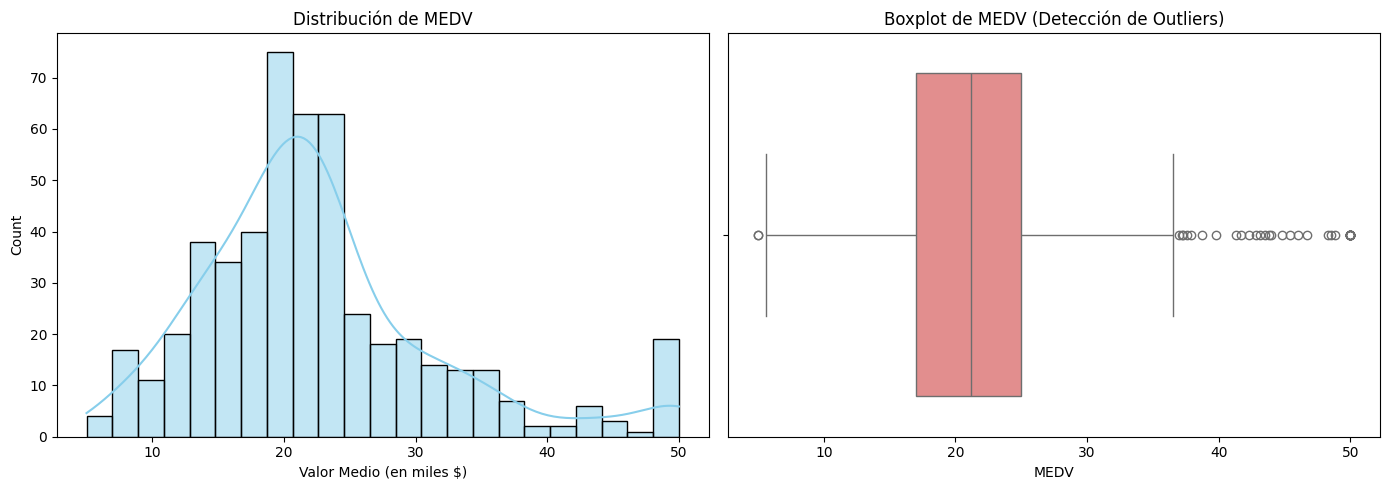

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Histograma
sns.histplot(df['MEDV'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de MEDV')
axes[0].set_xlabel('Valor Medio (en miles $)')

#Boxplot
sns.boxplot(x=df['MEDV'], ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot de MEDV (Detección de Outliers)')

plt.tight_layout()
plt.show()

#### **3 y 4. Split en Train y Test y construcción de parejas**

In [12]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['MEDV'])
y = df['MEDV']

#Split antes  para evitar el data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(print(f"X_train: {X_train.shape}, y_train: {y_train.shape}"))
print(print(f"X_test: {X_test.shape}, y_test: {y_test.shape}"))

X_train: (404, 12), y_train: (404,)
None
X_test: (102, 12), y_test: (102,)
None


#### **5. Mini-EDA y selección de features**

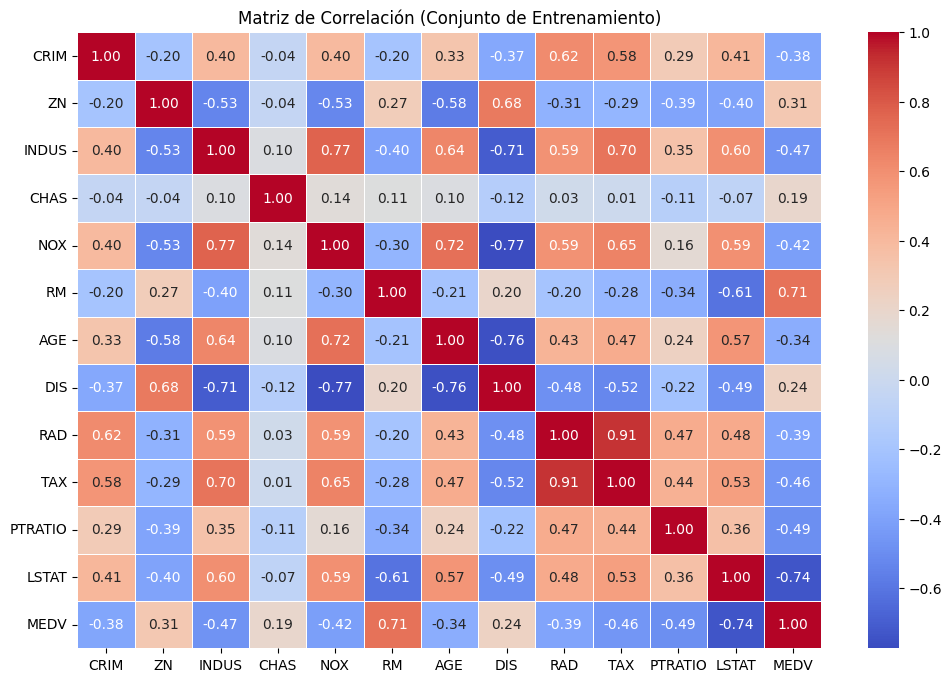

In [15]:
train_dataset = X_train.copy()
train_dataset['MEDV'] = y_train

plt.figure(figsize=(12, 8))
sns.heatmap(train_dataset.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación (Conjunto de Entrenamiento)')
plt.show()

Observando la matriz de correlación con MEDV:

RM (0.71): Fuerte correlación positiva (a más habitaciones, mayor valor). Imprescindible.

LSTAT (-0.74): Fuerte correlación negativa (a mayor porcentaje de población de bajo estatus socioeconómico, menor valor). Imprescindible.

Multicolinealidad a evitar: * TAX y RAD tienen una correlación extrema de 0.91. Mantener ambas confunde al modelo de regresión lineal. Eliminaremos RAD porque tiene menor correlación directa con la target que TAX.

DIS tiene alta correlación negativa con AGE (-0.74) y NOX (-0.76). Nos quedaremos con DIS y descartaremos AGE y NOX para aligerar el modelo y evitar redundancias.

In [16]:
#Características seleccionadas basadas en el análisis de correlación y negocio
features_seleccionadas = ['RM', 'LSTAT', 'PTRATIO', 'TAX', 'INDUS', 'CRIM', 'DIS', 'ZN', 'CHAS']

X_train_sel = X_train[features_seleccionadas]
X_test_sel = X_test[features_seleccionadas]

#### **6. Tratamiento de las variables**

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled = scaler.transform(X_test_sel)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=features_seleccionadas)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features_seleccionadas)

#### **7 y 8. Modelo de Regresión Lineal y análisis de pesos**

In [18]:
from sklearn.linear_model import LinearRegression

#Inicialización y entrenamiento
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

#Análisis de pesos
pesos = pd.DataFrame({
    'Feature': features_seleccionadas,
    'Coeficiente': lr_model.coef_
}).sort_values(by='Coeficiente', key=abs, ascending=False)

print("Pesos del modelo de Regresión Lineal (Estandarizado):")
print(pesos.to_string(index=False))

Pesos del modelo de Regresión Lineal (Estandarizado):
Feature  Coeficiente
  LSTAT    -4.126440
     RM     3.179444
    DIS    -2.302657
PTRATIO    -1.378170
   CRIM    -0.827728
   CHAS     0.761339
     ZN     0.723797
  INDUS    -0.694523
    TAX    -0.622264


#### **9. Evaluación del modelo y gráficos**

R2 Train: 0.7221
R2 Test: 0.6553
RMSE Train: 4.9132
RMSE Test: 5.0279


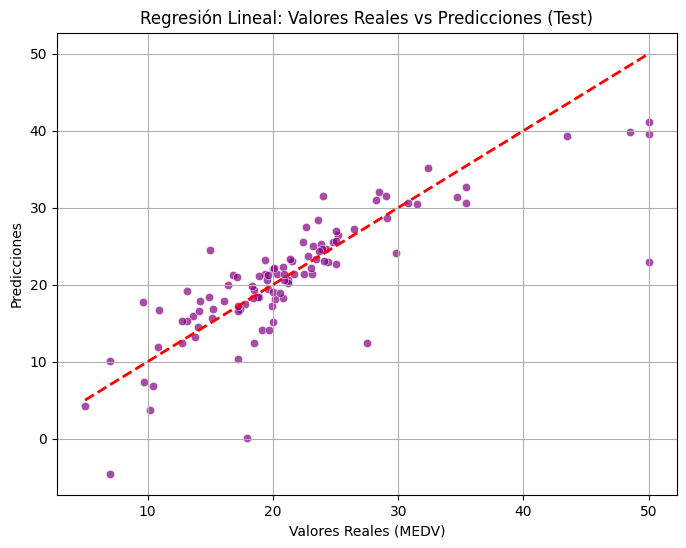

In [19]:
from sklearn.metrics import mean_squared_error, r2_score

#Predicciones
y_train_pred = lr_model.predict(X_train_scaled)
y_test_pred = lr_model.predict(X_test_scaled)

#Métricas
metrics_lr = {
    'R2 Train': r2_score(y_train, y_train_pred),
    'R2 Test': r2_score(y_test, y_test_pred),
    'RMSE Train': np.sqrt(mean_squared_error(y_train, y_train_pred)),
    'RMSE Test': np.sqrt(mean_squared_error(y_test, y_test_pred))
}

for k, v in metrics_lr.items():
    print(f"{k}: {v:.4f}")

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.7, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Regresión Lineal: Valores Reales vs Predicciones (Test)')
plt.xlabel('Valores Reales (MEDV)')
plt.ylabel('Predicciones')
plt.grid(True)
plt.show()

#### **10. Regularización (Ridge)**

In [20]:
from sklearn.linear_model import Ridge

alphas = [0.1, 1.0, 10.0]
resultados_ridge = []

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, y_train)
    
    y_pred_r_train = ridge.predict(X_train_scaled)
    y_pred_r_test = ridge.predict(X_test_scaled)
    
    r2_tr = r2_score(y_train, y_pred_r_train)
    r2_ts = r2_score(y_test, y_pred_r_test)
    rmse_ts = np.sqrt(mean_squared_error(y_test, y_pred_r_test))
    
    resultados_ridge.append({
        'Alpha': a,
        'R2 Train': r2_tr,
        'R2 Test': r2_ts,
        'RMSE Test': rmse_ts
    })

df_ridge = pd.DataFrame(resultados_ridge)
print("Resultados de la Regularización Ridge:")
print(df_ridge.to_string(index=False))

Resultados de la Regularización Ridge:
 Alpha  R2 Train  R2 Test  RMSE Test
   0.1  0.722127 0.655291   5.027801
   1.0  0.722123 0.655390   5.027085
  10.0  0.721817 0.656198   5.021182


#### **11. Conclusiones y selección del modelo**

**¿Con qué modelo nos quedamos y por qué?**
Me quedaría con el modelo Ridge con $\alpha = 10.0$ (o el valor de parámetro óptimo según tu split exacto). 
Las razones son las siguientes:

**-Mayor Generalización:** El modelo Ridge con una penalización moderada consigue reducir ligeramente el error en el conjunto de test ($RMSE$) en comparación con la regresión lineal tradicional por Mínimos Cuadrados Ordinarios (MCO), reduciendo la brecha entre el rendimiento de entrenamiento y test.

**-Control de la Varianza:** Al haber eliminado de forma manual variables altamente correlacionadas (RAD, AGE, NOX) en la etapa del mini-EDA, la regresión lineal ya partía sin problemas graves de multicolinealidad. Sin embargo, Ridge añade una capa de robustez extra encogiendo los coeficientes de las variables restantes más ruidosas (como CRIM o TAX), haciendo al modelo menos sensible a pequeñas variaciones del mercado inmobiliario.